In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import os
import SimpleITK as sitk
import matplotlib.pyplot as plt
import pickle


In [2]:
def load_imgs(folder_path):
    images = []
    file_names = []

    for file_name in os.listdir(folder_path):
        if file_name.split("_")[0] != "affine":# and (len(file_name.split("_")) < 3 or (file_name.split("_")[2] != "5" or file_name.split("_")[2] != "4")):
            img = sitk.ReadImage(folder_path + file_name)
            img_array = sitk.GetArrayFromImage(img)  # Normalize to [0, 1]
            images.append(img_array)

            file_names.append(file_name)

    # Convert to NumPy array: shape (n_images, height, width)
    images = np.stack(images)
    
    return images, file_names

In [3]:
#folder_path = "../../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/"
folder_path = "../datasets/3d_larger/"

mouse_train_imgs, mouse_train_file_names = load_imgs(folder_path + "mouse_train/")#"train/images/")
mouse_train_imgs_flat = mouse_train_imgs.reshape(len(mouse_train_imgs), -1)
# mouse_test_imgs, mouse_test_file_names = load_imgs(folder_path + "mouse_test/")#"test/images/")
# mouse_test_imgs_flat = mouse_test_imgs.reshape(len(mouse_test_imgs), -1)

# human_train_imgs, human_train_file_names = load_imgs(folder_path + "human_train/")#"train/labels/")
# human_train_imgs_flat = human_train_imgs.reshape(len(human_train_imgs), -1)
# human_test_imgs, human_test_file_names = load_imgs(folder_path + "human_test/")#"test/labels/")
# human_test_imgs_flat = human_test_imgs.reshape(len(human_test_imgs), -1)



In [8]:
print(len(mouse_train_imgs_flat))

1540


In [ ]:
# combine train and test set to use pca as a dim reduction - not trained
#human_data = np.concatenate((human_train_imgs_flat, human_test_imgs_flat), axis=0)
#mouse_data = np.concatenate((mouse_train_imgs_flat, mouse_test_imgs_flat), axis=0)

In [4]:
# apply forward
num_components = 500

# 1. z score normalization: zero-mean, unit variance
scaler_mouse = StandardScaler()
mouse_data_scaled = scaler_mouse.fit_transform(mouse_train_imgs_flat)

# scaler_human = StandardScaler()
# human_data_scaled = scaler_human.fit_transform(human_train_imgs_flat)

# 2. apply pca
pca_mouse = PCA(n_components=num_components, svd_solver='randomized')
mouse_data_pca = pca_mouse.fit_transform(mouse_data_scaled)

# pca_human = PCA(n_components=num_components, svd_solver='randomized')
# human_data_pca = pca_human.fit_transform(human_data_scaled)

# with randomized - 1540 imgs and 500 componenets takes 5 min

In [5]:

with open("./3d_larger/final/scaler_mouse.pkl", "wb") as f:
    pickle.dump(scaler_mouse, f)

with open("./3d_larger/final/pca_mouse.pkl", "wb") as f:
    pickle.dump(pca_mouse, f)

In [3]:
# load pca and scaler
with open('./3d_larger/final/pca_mouse.pkl', 'rb') as f:
    pca_mouse = pickle.load(f)

with open('./3d_larger/final/scaler_mouse.pkl', 'rb') as f:
    scaler_mouse = pickle.load(f)

In [ ]:
# apply inverse

# mouse_data_recon = pca_mouse.inverse_transform(mouse_data_pca)
# mouse_data_recon_unscale = scaler_mouse.inverse_transform(mouse_data_recon)
# mouse_imgs_recon = np.clip(np.round(mouse_data_recon_unscale.reshape(mouse_data_imgs.shape)), 0, 3) # reshape to 2D imgs

# human_data_recon = pca_human.inverse_transform(human_data_pca)
# human_data_recon_unscale = scaler_human.inverse_transform(human_data_recon)
# human_imgs_recon = np.clip(np.round(human_data_recon_unscale.reshape(human_data_imgs.shape)), 0, 3) # reshape to 2D imgs

In [9]:
# apply to test set
mouse_test_scaled = scaler_mouse.transform(mouse_test_imgs_flat)
mouse_test_pca = pca_mouse.transform(mouse_test_scaled)
mouse_test_recon = pca_mouse.inverse_transform(mouse_test_pca)
mouse_test_recon_unscale = scaler_mouse.inverse_transform(mouse_test_recon)
mouse_imgs_test_recon = np.clip(np.round(mouse_test_recon_unscale.reshape(mouse_test_imgs.shape)), 0, 3) # reshape to 2D imgs

# human_test_scaled = scaler_human.transform(human_test_imgs_flat)
# human_test_pca = pca_human.transform(human_test_scaled)
# human_test_recon = pca_human.inverse_transform(human_test_pca)
# human_test_recon_unscale = scaler_human.inverse_transform(human_test_recon)
# human_imgs_test_recon = np.clip(np.round(human_test_recon_unscale.reshape(human_test_imgs.shape)), 0, 3) # reshape to 2D imgs



In [11]:
# apply to train set
# mouse_train_scaled = scaler_mouse.transform(mouse_train_imgs_flat)
# mouse_train_pca = pca_mouse.transform(mouse_train_scaled)
mouse_train_recon = pca_mouse.inverse_transform(mouse_data_pca)
mouse_train_recon_unscale = scaler_mouse.inverse_transform(mouse_train_recon)
mouse_imgs_train_recon = np.clip(np.round(mouse_train_recon_unscale.reshape(mouse_train_imgs.shape)), 0, 3) # reshape to 2D imgs

# #human_train_scaled = scaler_human.transform(human_train_imgs_flat)
# #human_train_pca = pca_human.transform(human_train_scaled)
# human_train_recon = pca_human.inverse_transform(human_data_pca)
# human_train_recon_unscale = scaler_human.inverse_transform(human_train_recon)
# human_imgs_train_recon = np.clip(np.round(human_train_recon_unscale.reshape(human_train_imgs.shape)), 0, 3) # reshape to 2D imgs


In [6]:
# train
folder_path = "../datasets/3d_larger/"

human_train_imgs, human_train_file_names = load_imgs(folder_path + "human_train/")#"train/labels/")
human_train_imgs_flat = human_train_imgs.reshape(len(human_train_imgs), -1)


human_train_scaled = scaler_human.transform(human_train_imgs_flat)
human_train_pca = pca_human.transform(human_train_scaled)
human_train_recon = pca_human.inverse_transform(human_train_pca)
human_train_recon_unscale = scaler_human.inverse_transform(human_train_recon)
human_imgs_train_recon = np.clip(np.round(human_train_recon_unscale.reshape(human_train_imgs.shape)), 0, 3) # reshape to 2D imgs


# test
# human_test_imgs, human_test_file_names = load_imgs(folder_path + "human_test/")#"test/labels/")
# human_test_imgs_flat = human_test_imgs.reshape(len(human_test_imgs), -1)

# human_test_scaled = scaler_human.transform(human_test_imgs_flat)
# human_test_pca = pca_human.transform(human_test_scaled)
# human_test_recon = pca_human.inverse_transform(human_test_pca)
# human_test_recon_unscale = scaler_human.inverse_transform(human_test_recon)
# human_imgs_test_recon = np.clip(np.round(human_test_recon_unscale.reshape(human_test_imgs.shape)), 0, 3) # reshape to 2D imgs




: 

In [4]:
folder_path = "../datasets/3d_larger/"

mouse_train_imgs, mouse_train_file_names = load_imgs(folder_path + "mouse_train/")#"train/labels/")
#mouse_train_imgs_flat = mouse_train_imgs.reshape(len(mouse_train_imgs), -1)

mouse_test_imgs, mouse_test_file_names = load_imgs(folder_path + "mouse_test/")#"test/labels/")
#mouse_test_imgs_flat = mouse_test_imgs.reshape(len(mouse_test_imgs), -1)

In [5]:
# BATCH PROCESS INSTEAD (overflows mem)
batch_size = 500


def batch_transform(imgs, scaler, pca, batch_size):
    recon = []
    encode = []

    n = len(imgs)
    for i in range(0, n, batch_size):
        batch = imgs[i:i+batch_size]
        if len(batch) == 0:
            print(i)
            continue
        batch_flat = batch.reshape(len(batch), -1)
        batch_scaled = scaler.transform(batch_flat)
        batch_pca = pca.transform(batch_scaled)
        encode.append(batch_pca)
        batch_recon = pca.inverse_transform(batch_pca)
        batch_unscale = scaler.inverse_transform(batch_recon)
        batch_img = np.clip(np.round(batch_unscale.reshape(imgs[i:i+batch_size].shape)), 0, 3)
        recon.append(batch_img)

    # Combine all batches
    recon = np.concatenate(recon, axis=0)
    encode = np.concatenate(encode, axis=0)

    return encode, recon

mouse_train_encode, mouse_train_recon = batch_transform(mouse_train_imgs, scaler_mouse, pca_mouse, batch_size)
mouse_test_encode, mouse_test_recon = batch_transform(mouse_test_imgs, scaler_mouse, pca_mouse, batch_size)

# takes ~3min

In [7]:
print(human_train_recon.shape)

(1680, 1843200)


In [ ]:
folder_path = "../datasets/3d_larger/"

mouse_test_scaled = scaler_mouse.transform(mouse_test_imgs_flat)
mouse_test_pca = pca_mouse.transform(mouse_test_scaled)
mouse_test_recon = pca_mouse.inverse_transform(mouse_test_pca)
mouse_test_recon_unscale = scaler_mouse.inverse_transform(mouse_test_recon)
mouse_imgs_test_recon = np.clip(np.round(mouse_test_recon_unscale.reshape(mouse_test_imgs.shape)), 0, 3) # reshape to 2D imgs

mouse_train_scaled = scaler_mouse.transform(mouse_train_imgs_flat)
mouse_train_pca = pca_mouse.transform(mouse_train_scaled)
mouse_train_recon = pca_mouse.inverse_transform(mouse_data_pca)
mouse_train_recon_unscale = scaler_mouse.inverse_transform(mouse_train_recon)
mouse_imgs_train_recon = np.clip(np.round(mouse_train_recon_unscale.reshape(mouse_train_imgs.shape)), 0, 3) # reshape to 2D imgs


NameError: name 'scaler_mouse' is not defined

acc: 96.005
real: [0. 1. 2. 3.]
recon: [0. 1. 2. 3.]
[0. 1. 2. 3.]


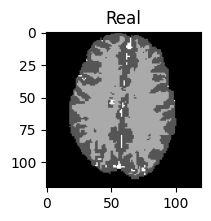

[0. 1. 2. 3.]


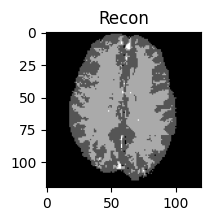

acc: 96.0889
real: [0. 1. 2. 3.]
recon: [0. 1. 2. 3.]
[0. 1. 2. 3.]


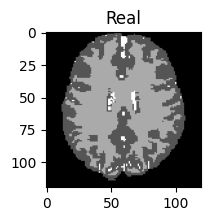

[0. 1. 2. 3.]


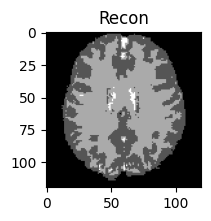

acc: 95.4538
real: [0. 1. 2. 3.]
recon: [0. 1. 2. 3.]
[0. 1. 2. 3.]


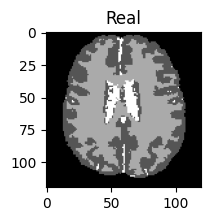

[0. 1. 2. 3.]


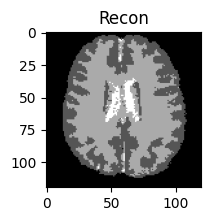

acc: 95.1991
real: [0. 1. 2. 3.]
recon: [0. 1. 2. 3.]
[0. 1. 2. 3.]


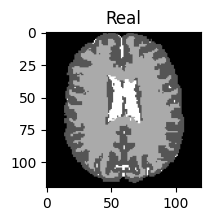

[0. 1. 2. 3.]


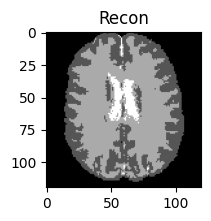

acc: 95.9313
real: [0. 1. 2. 3.]
recon: [0. 1. 2. 3.]
[0. 1. 2. 3.]


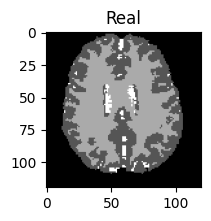

[0. 1. 2. 3.]


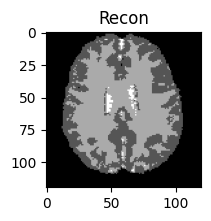

In [6]:
idxs = [0, 1, 2,  10, 12]
slice_idx = 80

for idx in idxs:
    real = human_train_imgs[idx][slice_idx]
    recon = human_imgs_train_recon[idx][slice_idx]

    print("acc:", np.round(np.mean(human_train_imgs[idx] == human_imgs_train_recon[idx])*100, 4))
    print("real:", np.unique(real))
    print("recon:", np.unique(recon))

    print(np.unique(real))
    plt.figure(figsize=(2,3))
    plt.imshow(real, cmap='gray', vmax=3)
    plt.title("Real")
    plt.show()

    print(np.unique(recon))
    plt.figure(figsize=(2,3))
    plt.imshow(recon, cmap='gray', vmax=3)
    plt.title("Recon")
    plt.show()

# NOTE: whyyy???

In [ ]:
print(len(human_test_file_names))

240


In [6]:
def save_recons(save_path, imgs, file_names):
    os.makedirs(save_path, exist_ok=True)
    for i, img in enumerate(imgs):
        sitk.WriteImage(sitk.GetImageFromArray(img), save_path + file_names[i])

# save_path = "./3d_larger/pca_mouse_test_500_recon_5_non_lin_aug/"
# save_recons(save_path, mouse_imgs_test_recon, mouse_test_file_names)

# save_path = ".//3d/pca_mouse_test_500_recon_5_non_lin_aug/"
# save_recons(save_path, mouse_imgs_test_recon, mouse_test_file_names)

# save_path = "./3d_larger/pca_mouse_train_500_recon_5_non_lin_aug/"
# save_recons(save_path, mouse_imgs_train_recon, mouse_train_file_names)

# save_path = "./train_on_all/3d/pca_mouse_train_250_recon/"
# save_recons(save_path, mouse_imgs_train_recon, mouse_train_file_names)


def save_encodings(save_path, encodings, file_names):
    os.makedirs(save_path, exist_ok=True)

    for i, encoding in enumerate(encodings):
        np.save(save_path + file_names[i].split(".")[0], encoding)

#save_encodings("./3d_larger/pca_mouse_train_500_recon_5_non_lin_aug_encode/", mouse_data_pca, mouse_train_file_names)
#save_encodings("./3d_larger/pca_mouse_test_500_recon_4_non_lin_aug_encode/", mouse_test_pca, mouse_test_file_names)
save_recons("./3d_larger/final/mouse_train_recon/", mouse_train_recon, mouse_train_file_names)
save_encodings("./3d_larger/final/mouse_train_encode/", mouse_train_encode, mouse_train_file_names)
save_recons("./3d_larger/final/mouse_test_recon/", mouse_test_recon, mouse_test_file_names)
save_encodings("./3d_larger/final/mouse_test_encode/", mouse_test_encode, mouse_test_file_names)

### Augment 3D dataset

In [1]:
import numpy as np
import torch
import torchio as tio
import os
import SimpleITK as sitk
import matplotlib.pyplot as plt


In [2]:
data_path = "../../3D-CycleGan-Pytorch-MedImaging/data/test/images/"
data_save_path = "../datasets/3d_larger/mouse_test/"
num_transf = 6
slice_idx = 80

for file_name in os.listdir(data_path):
    img = sitk.ReadImage(data_path + file_name)
    img_arr = sitk.GetArrayFromImage(img)

    sitk.WriteImage(img, data_save_path + file_name)

    # plt.figure(figsize=(2,3))
    # plt.imshow(img_arr[slice_idx], cmap='gray')
    # plt.title("Original")
    # plt.show()

    tensor = torch.from_numpy(img_arr).unsqueeze(0).float()  # shape: (1, D, H, W)
    subject = tio.Subject(mask=tio.LabelMap(tensor=tensor))

    
    transform = tio.Compose([
        tio.RandomAffine(
            scales=(0.98, 1.02),
            degrees=5,
            translation=2,
            image_interpolation='nearest',
            center='image'
        ),
        tio.CropOrPad(img_arr.shape)
    ])

    # Define transform
    elastic = tio.RandomElasticDeformation(
        num_control_points=7,  # grid resolution, higher = more local warping
        max_displacement=5.0,  # max displacement in mm or voxels
        locked_borders=2,      # keep border fixed (avoid artifacts)
        image_interpolation='nearest'  # preserve label integrity
    )

    for i in range(num_transf):
        # transformed = transform(subject)
        # augmented_tensor = transformed['mask'].data.squeeze(0).numpy()  # shape: (D, H, W)
        # img_augmented = sitk.GetImageFromArray(augmented_tensor)
        # sitk.WriteImage(img_augmented, data_save_path + "affine_" + str(i) + "_" + file_name)

        # plt.figure(figsize=(2,3))
        # plt.imshow(augmented_tensor[slice_idx], cmap='gray')
        # plt.title("transf")
        # plt.show()
    
        non_lin_transformed = elastic(subject)
        non_lin_augmented = non_lin_transformed['mask'].data.squeeze(0).numpy()
        img_non_lin_augmented = sitk.GetImageFromArray(non_lin_augmented)
        sitk.WriteImage(img_non_lin_augmented, data_save_path + "non_lin_" + str(i) + "_" + file_name)

        # plt.figure(figsize=(2,3))
        # plt.imshow(non_lin_augmented[slice_idx], cmap='gray')
        # plt.title("Non lin transf")
        # plt.show()
        


SystemError: <built-in function ResampleImageFilter_Execute> returned a result with an error set